In [ ]:
#!pip3 install optuna

In [19]:
import numpy as np
import pandas as pd

import warnings

from sklearn.preprocessing import PowerTransformer
import re

import xgboost as xgb
import lightgbm as lgb
from xgboost import plot_importance
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
import scipy.stats
from scipy.stats import norm
from sklearn.base import clone, BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, classification_report, confusion_matrix, accuracy_score, cohen_kappa_score
#import optuna

#import shap

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.figsize': (20, 16)})

In [2]:
# Import the features

df_feat=pd.read_csv('../data/features/mean_power_by_epochs_granular.csv')
df_feat.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(0, 5)_alpha","CL6_(0, 5)_beta","CL6_(0, 5)_delta","CL6_(0, 5)_lower gamma","CL6_(0, 5)_theta","CL6_(5, 10)_alpha","CL6_(5, 10)_beta","CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta"
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,1.537287e-09,3.561905e-10,4.908325e-09,6.962249e-11,1.729118e-09,1.202900e-09,3.501433e-10,5.478580e-09,5.951559e-11,1.423738e-09
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,1.211884e-09,3.354284e-10,5.194283e-09,6.609093e-11,1.488689e-09,9.004423e-10,3.843510e-10,7.098802e-09,6.475551e-11,1.285826e-09
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,1.663328e-09,4.766676e-10,4.582519e-09,6.637577e-11,1.316288e-09,1.119152e-09,3.557124e-10,2.524196e-09,5.997453e-11,1.505792e-09
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,1.236335e-09,4.668531e-10,3.786341e-09,7.868001e-11,1.832124e-09,1.673658e-09,3.526146e-10,4.241283e-09,6.952896e-11,1.686248e-09
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,1.190958e-09,4.125246e-10,5.845627e-09,8.286195e-11,1.713941e-09,9.169432e-10,3.606095e-10,4.427134e-09,7.090293e-11,1.798759e-09


In [3]:
df_feat.shape

(10709, 92)

In [4]:
df_feat.dtypes

subject_name                object
epoch                        int64
CL1_(-4, 0)_alpha          float64
CL1_(-4, 0)_beta           float64
CL1_(-4, 0)_delta          float64
                            ...   
CL6_(5, 10)_alpha          float64
CL6_(5, 10)_beta           float64
CL6_(5, 10)_delta          float64
CL6_(5, 10)_lower gamma    float64
CL6_(5, 10)_theta          float64
Length: 92, dtype: object

In [5]:
df_target = pd.read_csv('../data/target.csv')
df_target.head()

,Unnamed: 0,Participant,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity
0,0,1,H,6,6,6,5,6
1,1,1,H,6,6,6,5,5
2,2,1,H,6,6,6,5,6
3,3,1,H,6,6,5,6,6
4,4,1,H,6,6,5,4,5


In [6]:
df_target['subject_name']=['P10'+str(x) if len(str(x))<=1 else 'P1'+str(x) for x in df_target.Participant]

df_target = df_target.drop(columns=['Unnamed: 0', 'Participant'])
df_target.head()

,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity,subject_name
0,H,6,6,6,5,6,P101
1,H,6,6,6,5,5,P101
2,H,6,6,6,5,6,P101
3,H,6,6,5,6,6,P101
4,H,6,6,5,4,5,P101


In [7]:
df_target['epoch']=df_target.groupby(by='subject_name').cumcount()+1
df_target.head()

,PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity,subject_name,epoch
0,H,6,6,6,5,6,P101,1
1,H,6,6,6,5,5,P101,2
2,H,6,6,6,5,6,P101,3
3,H,6,6,5,6,6,P101,4
4,H,6,6,5,4,5,P101,5


In [8]:
df=pd.merge(df_feat,df_target,how='left',on=['subject_name','epoch'])
df.head()

,subject_name,epoch,"CL1_(-4, 0)_alpha","CL1_(-4, 0)_beta","CL1_(-4, 0)_delta","CL1_(-4, 0)_lower gamma","CL1_(-4, 0)_theta","CL1_(0, 5)_alpha","CL1_(0, 5)_beta","CL1_(0, 5)_delta",...,"CL6_(5, 10)_beta","CL6_(5, 10)_delta","CL6_(5, 10)_lower gamma","CL6_(5, 10)_theta",PoemType,Aesthetic_Appeal,Vivid_Imagery,Moved,Originality,Creativity
0,P101,1,9.088822e-10,2.072042e-10,3.287845e-09,7.816580e-11,1.656143e-09,1.303344e-09,2.988884e-10,5.732215e-09,...,3.501433e-10,5.478580e-09,5.951559e-11,1.423738e-09,H,6,6,6,5,6
1,P101,2,1.102854e-09,3.646768e-10,2.983556e-09,7.874124e-11,3.031881e-09,8.755720e-10,2.857535e-10,6.854427e-09,...,3.843510e-10,7.098802e-09,6.475551e-11,1.285826e-09,H,6,6,6,5,5
2,P101,3,1.119688e-09,3.283326e-10,5.693652e-09,6.170610e-11,1.940697e-09,1.635918e-09,3.778830e-10,6.764768e-09,...,3.557124e-10,2.524196e-09,5.997453e-11,1.505792e-09,H,6,6,6,5,6
3,P101,4,9.187232e-10,3.496927e-10,4.107768e-09,4.979888e-11,2.149611e-09,1.053823e-09,3.169192e-10,6.734609e-09,...,3.526146e-10,4.241283e-09,6.952896e-11,1.686248e-09,H,6,6,5,6,6
4,P101,5,1.066661e-09,3.380379e-10,2.458196e-09,5.411932e-11,1.880168e-09,1.419091e-09,3.662775e-10,6.364504e-09,...,3.606095e-10,4.427134e-09,7.090293e-11,1.798759e-09,H,6,6,5,4,5


In [9]:
# Exclude 4 subjects with less data
list_to_drop = ['P105','P141','P142','P146']

df_filtered = df[~df.subject_name.isin(list_to_drop)]

In [10]:
## Divide data into different stimuli

df_haiku = df_filtered[df_filtered.PoemType=='H']
df_senryu = df_filtered[df_filtered.PoemType=='S']
df_control = df_filtered[df_filtered.PoemType=='C']

In [11]:
datasets = {
    'haiku': df_haiku,
    'senryu': df_senryu,
    'control': df_control
}

In [12]:
# Keep original score variable as a target
cols_target = ['Aesthetic_Appeal','Vivid_Imagery','Moved', 'Originality', 'Creativity']

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    # Drop the poem type column
    df_copy = df_copy.drop(columns='PoemType')
    
    # Add df_copy to the dictionary of binary datasets
    datasets[stimulus] = df_copy

In [13]:
# Make X, y, train-test split for each stimulus
split_datasets = {}

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    X = df_copy.iloc[:,2:-5]
    y = df_copy.iloc[:,-5:]
    
    # Make one target variable out of 5 - to be removed in next iteration
#    y = y.median(axis=1)
    
    for col_target in cols_target:
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y[col_target], test_size=0.2, random_state=42,
                                                           stratify=y[col_target])
        
        stimulus_target = str(stimulus)+'_'+str(col_target)
    
        split_datasets[stimulus_target] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'X': X,
            'y': y[col_target]
        }

In [14]:
normalised_split_datasets = {}

for stimulus, df in datasets.items():
    # Create a copy of df
    df_copy = df.copy()
    
    X = df_copy.iloc[:,2:-5]
    y = df_copy.iloc[:,-5:]
    
    # Make one target variable out of 5 - to be removed in next iteration
    #y = y.median(axis=1)
    
    # Normalise the variables
    transformer = PowerTransformer(method='yeo-johnson')
    X_transformed = transformer.fit_transform(X)
    X_transformed = pd.DataFrame(X_transformed, columns=X.columns)
    
    # Train-test split
    for col_target in cols_target:
        X_train, X_test, y_train, y_test = train_test_split(X_transformed, y[col_target], test_size=0.2,
                                                            random_state=42, stratify=y[col_target])
    
        stimulus_target = str(stimulus)+'_'+str(col_target)
        
        normalised_split_datasets[stimulus_target] = {
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'X_transformed': X_transformed,
            'y': y[col_target]
        }

In [15]:
normalised_split_datasets['haiku_Aesthetic_Appeal']['y'].value_counts()

5    1110
4     740
6     644
3     334
7     270
2     135
1      57
Name: Aesthetic_Appeal, dtype: int64

# Linear models

## Ordinal classifier with sklearn Logistic Regression and GridsearchCV

In [28]:
# Threshold modeling: create binary classifiers for each class threshold
class OrdinalClassifier:
    def __init__(self, base_model=LogisticRegression()):
        self.base_model = base_model
        self.models = []
    
    def fit(self, X, y):
        # Train multiple binary classifiers, one for each threshold (1 vs 2 and above, 2 vs 3 and above, etc.)
        self.classes_ = np.sort(np.unique(y))
        self.models = []
        
        for threshold in self.classes_[:-1]:  # We stop at the second-to-last class
            binary_y = (y > threshold).astype(int)
            model = clone(self.base_model)  # Clone the model for each threshold
            model.fit(X, binary_y)
            self.models.append(model)
            
            # Get the coefficients
            self.coefficients_ = model.coef_.flatten()  # Flatten if it's multi-class
            self.intercept_ = model.intercept_
        
            # Predict probabilities
            probas = model.predict_proba(X)
        
            # Calculate the Hessian matrix
            # The Hessian matrix is needed to calculate standard errors
            hessian = self._compute_hessian(X, probas, binary_y)

            # Inverse of Hessian gives the covariance matrix
            covariance_matrix = np.linalg.inv(hessian)

            # Standard errors are the square root of the diagonal of the covariance matrix
            self.standard_errors_ = np.sqrt(np.diag(covariance_matrix))

            # Calculate p-values
            z_scores = self.coefficients_ / self.standard_errors_
            self.p_values_ = 2 * (1 - norm.cdf(np.abs(z_scores)))  # Two-tailed test
    
    def predict_proba(self, X):
        # Predict cumulative probabilities
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        probas = np.zeros((n_samples, n_classes))

        for i, model in enumerate(self.models):
            p = model.predict_proba(X)[:, 1]  # Get the probability of being > threshold
            probas[:, i + 1] = p

        probas[:, 0] = 1 - probas[:, 1]  # The first class is 1 minus the first threshold
        for i in range(1, n_classes - 1):
            probas[:, i] -= probas[:, i + 1]

        return probas

    def predict(self, X):
        probas = self.predict_proba(X)
        return np.argmax(probas, axis=1) + 1  # Add 1 to match the ordinal class labels

    # Implement get_params and set_params for compatibility with GridSearchCV
    def get_params(self, deep=True):
        return {"base_model": self.base_model}

    def set_params(self, **params):
        self.base_model = params.get("base_model", self.base_model)
        return self
    
    def _compute_hessian(self, X, probas, y):
        """Compute the Hessian matrix for the logistic regression."""
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        hessian = np.zeros((n_classes - 1, n_classes - 1))

        for i in range(n_samples):
            for j in range(n_classes - 1):
                for k in range(n_classes - 1):
                    if j == k:
                        hessian[j, k] -= probas[i, j] * (1 - probas[i, j])
                    else:
                        hessian[j, k] += probas[i, j] * probas[i, k]

        return hessian

In [32]:
linear_results = {}

# Linear model - sklearn loop

for stimulus_target, df in normalised_split_datasets.items():
    
    print("Running sklearn ordinal linear regression for ", stimulus_target)
    
    # Grid search parameters
    param_grid_linear = {
    'C': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],  # Specifies the norm used in the penalization
    'solver': ['liblinear', 'saga']  # Algorithm to use in the optimization problem
    }
    
    # Initialise model object and run the grid search
    
    # Ignore warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        log_reg = OrdinalClassifier(base_model=LogisticRegression(max_iter=1000))
        grid_search_linear = GridSearchCV(estimator=log_reg, param_grid=param_grid_linear, cv=5, 
                                          scoring='roc_auc_ovr', verbose=False)
        grid_search_linear.fit(df['X_train'], df['y_train'])
        print('Best Parameters: ', grid_search_linear.best_params_)
    
        # Predictions and performance metrics
        y_pred_linear = grid_search_linear.predict(df['X_test'])
        # Print classification report
        print(classification_report(df['y_test'], y_pred_linear))
        print("-----------------------")
        # Confusion matrix
        cm_linear = confusion_matrix(df['y_test'], y_pred_linear)
        print('Confusion Matrix:\n', cm_linear)
        print("-----------------------")
        # Compute the ROC AUC score
        # Predict probabilities and ROC AUC score
        y_prob = grid_search_linear.predict_proba(df['X_test'])

        # Compute ROC AUC score for each class
        y_val_binarized = LabelBinarizer().fit_transform(df['y_test'])
        roc_auc_linear = roc_auc_score(y_val_binarized, y_prob, average="macro", multi_class="ovr")
        print('ROC AUC: ', roc_auc_linear)
        
        # Compute Cohen's kappa
        kappa_score_linear = cohen_kappa_score(y_pred_linear, df['y_test'])
        print(f"Cohen's Kappa Score: {kappa_score_linear:.8f}")
        
        # Retrain on all data
        log_reg_best = OrdinalClassifier(base_model=LogisticRegression(**grid_search_linear.best_params_))
        log_reg_best.fit(df['X_transformed'],df['y'])
        
        # Save results
        linear_results[stimulus_target] = {
            'best_params': grid_search_linear.best_params_,
            'roc_auc': roc_auc_linear,
            'kappa_score': kappa_score_linear,
            'features': df['X_transformed'].columns,
            'params': log_reg_best.coefficients_,
            'p_values': log_reg_best.p_values_
        }
        
        

Running sklearn ordinal linear regression for  haiku_Aesthetic_Appeal
Best Parameters:  {'C': 1e-05, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.25      0.07      0.11        27
           3       0.21      0.04      0.07        67
           4       0.35      0.26      0.30       148
           5       0.38      0.67      0.48       222
           6       0.24      0.19      0.21       129
           7       0.21      0.11      0.15        54

    accuracy                           0.34       658
   macro avg       0.23      0.19      0.19       658
weighted avg       0.30      0.34      0.30       658

-----------------------
Confusion Matrix:
 [[  0   1   0   4   6   0   0]
 [  0   2   2   7  14   2   0]
 [  0   1   3  16  38   8   1]
 [  1   0   0  39  86  19   3]
 [  2   3   5  26 148  34   4]
 [  2   1   2  15  71  24  14]
 [  1   0   2   6  26  13   6]]
-

Best Parameters:  {'C': 1e-05, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           1       0.17      0.05      0.08        20
           2       0.38      0.12      0.19        40
           3       0.12      0.04      0.06        73
           4       0.26      0.22      0.24       147
           5       0.38      0.69      0.49       223
           6       0.19      0.13      0.15       117
           7       0.00      0.00      0.00        38

    accuracy                           0.32       658
   macro avg       0.21      0.18      0.17       658
weighted avg       0.26      0.32      0.27       658

-----------------------
Confusion Matrix:
 [[  1   2   2   1  11   3   0]
 [  2   5   2   6  21   4   0]
 [  0   2   3  15  39  14   0]
 [  2   3   6  33  81  21   1]
 [  1   0   8  44 154  16   0]
 [  0   1   4  17  77  15   3]
 [  0   0   1   9  22   6   0]]
-----------------------
ROC AUC:  0.6039071300169973
Cohen's Kappa Scor

## Statsmodel OrderedModel version with Gridsearch (no regularisation)

In [96]:
linear_results_sm = {}

# Linear model - statsmodels loop

for stimulus_target, df in normalised_split_datasets.items():
    
    print("Running sm linear regression for ", stimulus_target)
    
    # Grid search parameters
    # Define the alpha values to search over
    hyperparameters = {
    'distr': ['logit', 'probit'],  # Different link functions
    'method': ['lbfgs', 'cg', 'powell'],  # Optimization methods
    }

    # Create a KFold object for cross-validation
    kf = KFold(n_splits=5)

    # Initialize the best alpha and highest score
    # Manual grid search
    best_score = -np.inf
    best_kappa = -np.inf
    best_params = None
    best_model = None

    # Ignore warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        for distr in hyperparameters['distr']:
            for method in hyperparameters['method']:
                # Initialize the cross-validation score
                cv_score = 0
    
                # Perform cross-validation
                for train_index, val_index in kf.split(df['X_train']):
                    # Split the data
                    X_train_cv, X_val_cv = df['X_train'].iloc[train_index], df['X_train'].iloc[val_index]
                    y_train_cv, y_val_cv = df['y_train'].iloc[train_index], df['y_train'].iloc[val_index]
        
                    # Reset the indices
                    X_train_cv.reset_index(drop=True, inplace=True)
                    X_val_cv.reset_index(drop=True, inplace=True)
                    y_train_cv.reset_index(drop=True, inplace=True)
                    y_val_cv.reset_index(drop=True, inplace=True)
        
                    # Add a constant to the features
                    X_train_sm = sm.add_constant(X_train_cv)
                    X_val_sm = sm.add_constant(X_val_cv)
        
                    # Train the ordinal model
                    model = OrderedModel(y_train_cv, X_train_cv, distr=distr)
                    ordinal_model_fit = model.fit(method=method, disp=False)
        
                    # Predict the validation set results
                    y_prob = ordinal_model_fit.predict(X_val_cv)
                
                    # Convert cumulative probabilities to class probabilities
                    y_prob_class = np.column_stack([y_prob.iloc[:, 0], np.diff(y_prob, axis=1)])

                    # Calculate ROC AUC score
                    y_val_binarized = LabelBinarizer().fit_transform(y_val_cv)
                    roc_auc = roc_auc_score(y_val_binarized, y_prob_class, average="macro", multi_class="ovr")
                    #print(f"Params: distr={distr}, method={method}, ROC AUC: {roc_auc:.4f}")
                
                    # Predict class labels for validation set
                    predicted_probabilities = ordinal_model_fit.model.predict(ordinal_model_fit.params, 
                                                                          exog=X_val_cv)
                    predicted_classes = np.argmax(predicted_probabilities, axis=1) + 1  # +1 to adjust for 1-based classes

                    # Compute Cohen's Kappa
                    kappa_score_sm = cohen_kappa_score(y_val_cv, predicted_classes)

                    # Update the best model if the score is higher
                    if roc_auc > best_score:
                        best_score = roc_auc
                        best_kappa = kappa_score_sm
                        best_params = {'distr': distr, 'method': method}
                        best_model = ordinal_model_fit

                # Add a constant to the features
                #X_sm = sm.add_constant(df['X_transformed'])
                #X_sm.reset_index(drop=True, inplace=True)
                y_sm = df['y'].reset_index(drop=True)
            
                sm_best = OrderedModel(y_sm, df['X_transformed'], distr=best_params['distr'])
            
                # Fit the model with L1 regularization
                best_result = sm_best.fit(method=best_params['method'], disp=False)
        
                # Print the summary and scores
                #print('ROC AUC', best_score)
                #print('Cohen\'s Kappa score', best_kappa)
                #print(best_result.summary())
        
                # Save results
                linear_results_sm[stimulus_target] = {
                    'roc_auc': best_score,
                    'kappa_score': best_kappa,
                    'features': list(df['X_transformed'].columns),  # Ensure features are saved correctly
                    'params': list(best_result.params.values),  # Explicitly convert to list
                    'p_values': list(best_result.pvalues)  # Explicitly convert to list
                }

Running sm linear regression for  haiku_Aesthetic_Appeal
Running sm linear regression for  haiku_Vivid_Imagery
Running sm linear regression for  haiku_Moved
Running sm linear regression for  haiku_Originality
Running sm linear regression for  haiku_Creativity
Running sm linear regression for  senryu_Aesthetic_Appeal
Running sm linear regression for  senryu_Vivid_Imagery
Running sm linear regression for  senryu_Moved
Running sm linear regression for  senryu_Originality
Running sm linear regression for  senryu_Creativity
Running sm linear regression for  control_Aesthetic_Appeal
Running sm linear regression for  control_Vivid_Imagery
Running sm linear regression for  control_Moved
Running sm linear regression for  control_Originality
Running sm linear regression for  control_Creativity


In [97]:
for stimulus_target, results in linear_results_sm.items():
    print(stimulus_target)
    print(results['roc_auc'])
    print(results['kappa_score'])

haiku_Aesthetic_Appeal
0.582222423580129
0.010657755702998761
haiku_Vivid_Imagery
0.6207286668358581
0.07793067574596868
haiku_Moved
0.542464593112652
0.07042343484370561
haiku_Originality
0.573320569600782
0.0454773606032024
haiku_Creativity
0.5921710880835924
0.039310480840471396
senryu_Aesthetic_Appeal
0.5765819161822059
0.03964278702636326
senryu_Vivid_Imagery
0.5537844856633748
0.045278257542067046
senryu_Moved
0.532620072502597
0.027717239716539943
senryu_Originality
0.5692893242879185
-0.0014105198164726662
senryu_Creativity
0.5590367256946566
0.0251954060891475
control_Aesthetic_Appeal
0.5584771230342997
0.08956851200697791
control_Vivid_Imagery
0.5450265087426971
0.08658624448098118
control_Moved
0.5559800403481912
0.0834185412406272
control_Originality
0.5687935385512958
0.1169154228855721
control_Creativity
0.5422110447013739
0.09873687787931418


In [98]:
linear_coef =  {}
linear_coef_df = pd.DataFrame(columns=['Stimulus','TargetScore','features','params','p_values'])

for stimulus_target, results in linear_results_sm.items():
    dict_feat_only = linear_results_sm[stimulus_target]
    dict_feat_only['params'] = dict_feat_only['params'][:-6]
    dict_feat_only['p_values'] = dict_feat_only['p_values'][:-6]
    
    # Select only 'params' and 'p_values' from the dictionary
    dict_subset = {key: dict_feat_only[key] for key in ['features', 'params', 'p_values']}
    
    df_coef = pd.DataFrame.from_dict(dict_subset).reset_index(drop=True)
    
    # Remove special characters from feature names
    #df_coef['params'] = [re.sub(r'[^\w\s]', '', x) for x in df_coef['params']]
    
    linear_coef[stimulus_target] = df_coef
    
    df_coef2 = df_coef.copy()
    df_coef2['Stimulus'] = stimulus_target.split("_")[0].capitalize()
    str_target = stimulus_target.split("_")[1:]
    df_coef2['TargetScore'] = f"{'_'.join(str_target)}"
    
    linear_coef_df = pd.concat([linear_coef_df, df_coef2], ignore_index=True)
    

In [99]:
linear_coef_df['params_significant'] = [x if y<0.05 else 0 for (x,y) in zip(linear_coef_df.params,linear_coef_df.p_values)]
linear_coef_df[linear_coef_df.params_significant!=0].shape

(344, 6)

In [100]:
linear_coef_df.shape

(1350, 6)

In [104]:
def get_hierarchy_feature_names(features):
    cluster = []
    time_period = []
    frequency = []
    for feature in features:
        parts = feature.split('_')  # Split feature into parts
        cluster.append(parts[0])  # CL1, CL2, ...
        time_period.append(parts[1])  # (-4, 0), (0, 5), (5, 10)
        frequency.append(parts[2])  # alpha, beta, delta, lower gamma, theta
    return pd.DataFrame({
        'Cluster': cluster,
        'Time Period': time_period,
        'Frequency': frequency
    }, index=features)

# Get the hierarchical feature names
hierarchical_features = get_hierarchy_feature_names(normalised_split_datasets['haiku_Aesthetic_Appeal']['X_train'].columns)
hierarchical_features.head()

,Cluster,Time Period,Frequency
"CL1_(-4, 0)_alpha",CL1,"(-4, 0)",alpha
"CL1_(-4, 0)_beta",CL1,"(-4, 0)",beta
"CL1_(-4, 0)_delta",CL1,"(-4, 0)",delta
"CL1_(-4, 0)_lower gamma",CL1,"(-4, 0)",lower gamma
"CL1_(-4, 0)_theta",CL1,"(-4, 0)",theta


In [105]:
linear_coef_df = pd.merge(linear_coef_df,hierarchical_features, left_on='features', right_index=True)
linear_coef_df.head()

,Stimulus,TargetScore,features,params,p_values,params_significant,Cluster,Time Period,Frequency
0,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.046200,0.474638,0.0,CL1,"(-4, 0)",alpha
90,Haiku,Vivid_Imagery,"CL1_(-4, 0)_alpha",0.023550,0.717638,0.0,CL1,"(-4, 0)",alpha
180,Haiku,Moved,"CL1_(-4, 0)_alpha",0.204878,0.065852,0.0,CL1,"(-4, 0)",alpha
270,Haiku,Originality,"CL1_(-4, 0)_alpha",0.119555,0.289611,0.0,CL1,"(-4, 0)",alpha
360,Haiku,Creativity,"CL1_(-4, 0)_alpha",0.098948,0.374828,0.0,CL1,"(-4, 0)",alpha


In [106]:
linear_coef_df.to_csv('linear_coef_sign.csv', index=False)

# LightGBM ordinal model

In [84]:
# Initialize dictionary to store results
lgb_results_matrix = {key: {} for key in split_datasets.keys()}

lightgbm_results = {}

# LightGBM model training and saving loop
for stimulus_target, df in split_datasets.items():
    print("Running LightGBM model for", stimulus_target)
    
    # Clean column names
    df['X'].columns = [re.sub(r'[^\w\s]', '', col) for col in df['X'].columns]
    df['X_test'].columns = [re.sub(r'[^\w\s]', '', col) for col in df['X_test'].columns]
    
    # Define a filename to save search progress
    checkpoint_filename = "lightgbm_search_progress.pkl"
    # Define the parameter grid
    param_distributions = {
        "boosting_type": ["gbdt", "dart"],
        "num_leaves": np.arange(20, 101, 10),
        "learning_rate": np.logspace(-4, -1, 10),
        "n_estimators": np.arange(100, 801, 100),
        "min_data_in_leaf": np.arange(10, 101, 10),
        "lambda_l1": np.linspace(0.0, 10.0, 10),
        "lambda_l2": np.linspace(0.0, 10.0, 10),
        "feature_fraction": np.linspace(0.5, 1.0, 6),
        "bagging_fraction": np.linspace(0.5, 1.0, 6),
        "bagging_freq": np.arange(1, 8),
        "max_depth": np.arange(3, 12),
    }

    # Initialize LightGBM classifier
    lgbm_model = lgb.LGBMClassifier(objective="multiclass", num_class=7, random_state=42)

    # Check if previous search progress exists
    if os.path.exists(checkpoint_filename):
        print("Loading previous search progress...")
        random_search = joblib.load(checkpoint_filename)
    else:
        print("Starting a new hyperparameter search...")
        random_search = RandomizedSearchCV(
            estimator=lgbm_model,
            param_distributions=param_distributions,
            n_iter=30,  # Number of iterations
            scoring="roc_auc_ovr",
            cv=3,
            verbose=-1,
            random_state=42,
            n_jobs=2,
        )

    # Fit the randomized search with checkpoints
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for i in range(1, 51):  # 50 iterations
            print(f"Running iteration {i} of 50...")
        
            # Fit one iteration at a time
            random_search.n_iter = i
            random_search.fit(df["X"], df["y"])
        
            # Save progress every 10 iterations
            if i % 10 == 0:
                print(f"Saving progress at iteration {i}...")
                joblib.dump(random_search, checkpoint_filename)

    # Save final best parameters
    lgb_best_params = random_search.best_params_
    print("Best Parameters:", lgb_best_params)

    # Evaluate Model
    y_pred = random_search.predict(df["X_test"])
    y_pred_proba = random_search.predict_proba(df["X_test"])

    print(classification_report(df["y_test"], y_pred))
    print("Confusion Matrix:\n", confusion_matrix(df["y_test"], y_pred))

    # Compute ROC AUC score and Cohen's Kappa
    lgb_roc_auc = roc_auc_score(LabelBinarizer().fit_transform(df["y_test"]), y_pred_proba, average="macro", multi_class="ovr")
    lgb_kappa = cohen_kappa_score(df["y_test"], y_pred, weights="quadratic")
    print("ROC AUC:", lgb_roc_auc)
    print("Cohen's Kappa:", lgb_kappa)

    # Retrain the best model on all data
    lgbm_model_final = lgb.LGBMClassifier(**lgb_best_params, objective="multiclass", num_class=7, verbose=-1)
    #lgbm_model_final.fit(df["X"], df["y"])
    lgbm_model_final.fit(
        df["X"],
        df["y"],
        eval_set=[(df["X_test"], df["y_test"])],  # Use validation set for stopping
        eval_metric="multi_logloss",
        early_stopping_rounds=20,
        verbose=10
    )

    # Save final model
    model_filename = f"lightgbm_model_{stimulus_target}.joblib"
    joblib.dump(lgbm_model_final, model_filename)

    print("Final model saved successfully!")
    
    # Store the results
    lightgbm_results[stimulus_target] = {
        'best_params': lgb_best_params,
        'roc_auc': lgb_roc_auc,
        'kappa_score': lgb_kappa,
        'features': df['X'].columns,
        'feature_importances': lgbm_model_final.feature_importances_,
        'model_file': model_filename
    }
    
    if 'performance' not in lgb_results_matrix[stimulus_target]:
        lgb_results_matrix[stimulus_target]['performance'] = {}
        
        # Evaluate on all other datasets
    for test_stimulus_target, test_df in split_datasets.items():
        print(f"Evaluating {stimulus_target} model on {test_stimulus_target}")
        
        # Clean column names
        test_df['X_test'].columns = [re.sub(r'[^\w\s]', '', col) for col in test_df['X_test'].columns]
            
        # Make predictions and calculate probabilities
        y_pred_test = lgbm_model_final.predict(test_df['X_test'])
        y_prob_test = lgbm_model_final.predict_proba(test_df['X_test'])

        # Compute metrics
        cm_lgb = confusion_matrix(test_df['y_test'], y_pred_test)
        roc_auc_lgb = roc_auc_score(LabelBinarizer().fit_transform(test_df['y_test']), y_prob_test, 
                                    average="macro", multi_class="ovr")
        kappa_score_lgb = cohen_kappa_score(test_df['y_test'], y_pred_test, weights='quadratic')

        # Save results in the matrix
            
        lgb_results_matrix[stimulus_target]['performance'][test_stimulus_target] = {
            'roc_auc': roc_auc_lgb,
            'kappa_score': kappa_score_lgb,
            'confusion_matrix': cm_lgb
            }
            
        print(f"ROC AUC ({stimulus_target} on {test_stimulus_target}): {roc_auc_lgb}")
        print(f"Cohen's Kappa ({stimulus_target} on {test_stimulus_target}): {kappa_score_lgb}")
        print("Confusion Matrix:\n", cm_lgb)
        print("-----------------------")

Running LightGBM model for  haiku_Aesthetic_Appeal
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] min_data_in_leaf is set=40, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=40
[LightGBM] [Warning] lambda_l1 is set=6.666666666666667, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.666666666666667
Best Parameters:  {'num_leaves': 40, 'n_estimators': 900, 'min_data_in_leaf': 40, 'max_depth': 4, 'learning_rate': 0.002154434690031882, 'lambda_l2': 1.1111111111111112, 'lambda_l1': 6.666666666666667, 'feature_fr

/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Running LightGBM model for  haiku_Vivid_Imagery
Best Parameters:  {'num_leaves': 30, 'n_estimators': 300, 'min_data_in_leaf': 10, 'max_depth': 7, 'learning_rate': 0.002154434690031882, 'lambda_l2': 2.2222222222222223, 'lambda_l1': 8.88888888888889, 'feature_fraction': 0.9, 'boosting_type': 'dart', 'bagging_freq': 5, 'bagging_fraction': 0.7}
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        19
           3       0.00      0.00      0.00        40
           4       0.00      0.00      0.00        78
           5       0.48      0.71      0.57       211
           6       0.47      0.76      0.58       208
           7       1.00      0.09      0.16        92

    accuracy                           0.48       658
   macro avg       0.28      0.22      0.19       658
weighted avg       0.44      0.48      0.39       658

-----------------------
Confusion Matrix:
 [[  0   0   0   0

/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1327: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Running LightGBM model for  haiku_Moved
Best Parameters:  {'num_leaves': 100, 'n_estimators': 400, 'min_data_in_leaf': 50, 'max_depth': 4, 'learning_rate': 0.0001, 'lambda_l2': 4.444444444444445, 'lambda_l1': 8.88888888888889, 'feature_fraction': 0.8, 'boosting_type': 'gbdt', 'bagging_freq': 4, 'bagging_fraction': 0.6}
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        45
           2       0.00      0.00      0.00        53
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00       162
           5       0.29      1.00      0.45       192
           6       0.00      0.00      0.00        94
           7       0.00      0.00      0.00        28

    accuracy                           0.29       658
   macro avg       0.04      0.14      0.06       658
weighted avg       0.09      0.29      0.13       658

-----------------------
Confusion Matrix:
 [[  0   0   0   0  45   0   0]
 [  0   

...

[LightGBM] [Warning] min_data_in_leaf is set=70, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=70
[LightGBM] [Warning] lambda_l1 is set=7.777777777777779, reg_alpha=0.0 will be ignored. Current value: lambda_l1=7.777777777777779
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=4.444444444444445, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.444444444444445
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] lambda_l1 is set=8.88888888888889, reg_alpha=0.0 will be ignored. Current value: lambda_l1=8.88888888888889
[LightGBM] [War

[LightGBM] [Warning] lambda_l2 is set=1.1111111111111112, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.1111111111111112
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] lambda_l1 is set=10.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=10.0
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] lambda_l2 is set=6.666666666666667, reg_lambda=0.0 will be ignored. Current value: lambda_l2=6.666666666666667
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] lambda_l1 is se

[LightGBM] [Warning] lambda_l2 is set=8.88888888888889, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.88888888888889
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] lambda_l1 is set=2.2222222222222223, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.2222222222222223
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] lambda_l2 is set=6.666666666666667, reg_lambda=0.0 will be ignored. Current value: lambda_l2=6.666666666666667
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [

[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=0.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] lambda_l1 is set=5.555555555555555, reg_alpha=0.0 will be ignored. Current value: lambda_l1=5.555555555555555
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.

[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] lambda_l2 is set=7.777777777777779, reg_lambda=0.0 will be ignored. Current value: lambda_l2=7.777777777777779
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=3.3333333333333335, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.3333333333333335
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] feature_fraction is set=1.0, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1.0
[LightGBM] [Warning] bagging_fra

In [85]:
# Extract ROC AUC scores from the results matrix
roc_auc_data_lgb = {
    (train_target, test_target): results['roc_auc']
    for train_target, evaluations in lgb_results_matrix.items()
    for test_target, results in evaluations['performance'].items()
}

# Extract kappa from the results matrix
kappa_data_lgb = {
    (train_target, test_target): results['kappa_score']
    for train_target, evaluations in lgb_results_matrix.items()
    for test_target, results in evaluations['performance'].items()
}

# Convert to DataFrame for seaborn heatmap (index=rows, columns=columns)
roc_auc_df_lgb = pd.DataFrame.from_dict(roc_auc_data_lgb, orient='index')
roc_auc_df_lgb.index = pd.MultiIndex.from_tuples(roc_auc_df_lgb.index, names=["Train", "Test"])
roc_auc_df_lgb = roc_auc_df_lgb.unstack(level='Test')

kappa_df_lgb = pd.DataFrame.from_dict(kappa_data_lgb, orient='index')
kappa_df_lgb.index = pd.MultiIndex.from_tuples(kappa_df_lgb.index, names=["Train", "Test"])
kappa_df_lgb = kappa_df_lgb.unstack(level='Test')

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(roc_auc_df_lgb, annot=True, cmap="coolwarm", fmt=".3f", cbar_kws={'label': 'ROC AUC'}, center=0.5)
plt.title("ROC AUC Scores for Ordinal Classifiers on Different Stimulus-Target Pairs")
plt.xlabel("Test Stimulus-Target Pair")
plt.ylabel("Train Stimulus-Target Pair")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [106]:
roc_auc_df_lgb.to_csv('streamlit_app/model_performance.csv', index=False)

In [107]:
# Load the dataset
df = pd.read_csv('streamlit_app/model_performance.csv', skiprows=1)  # Keep first column as index
df.index = df.columns
df

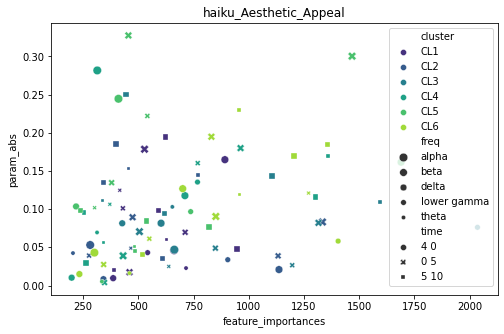

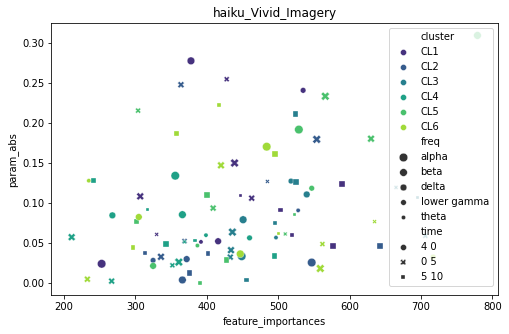

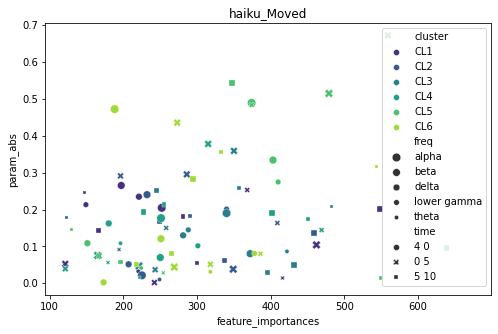

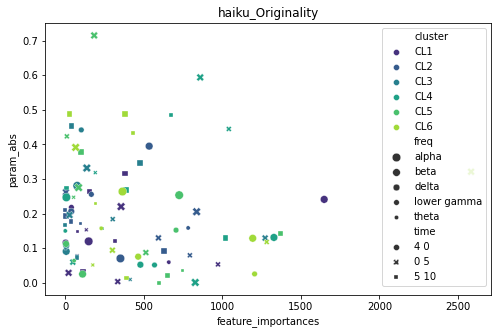

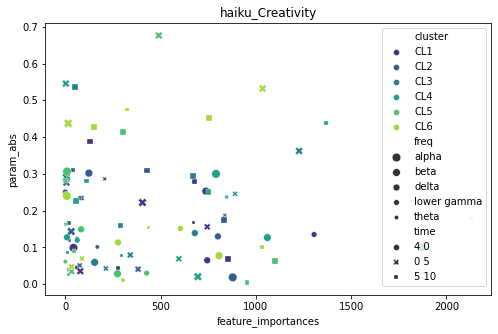

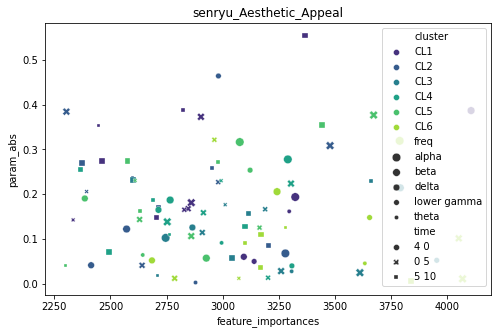

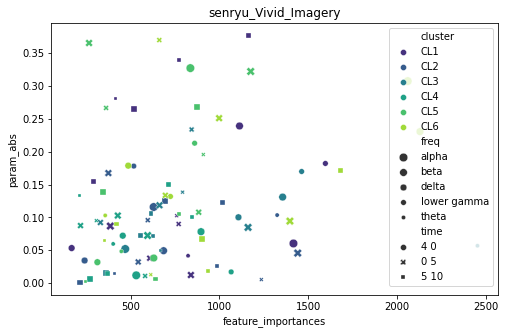

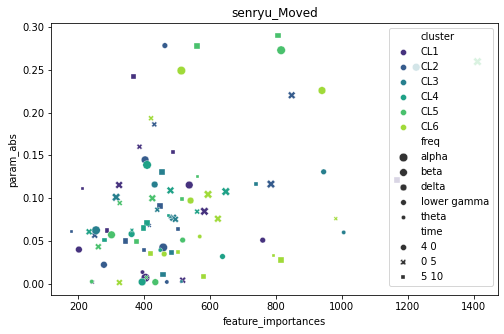

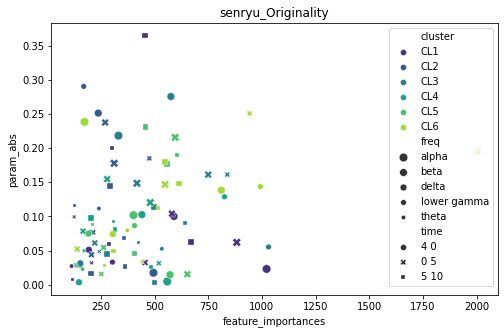

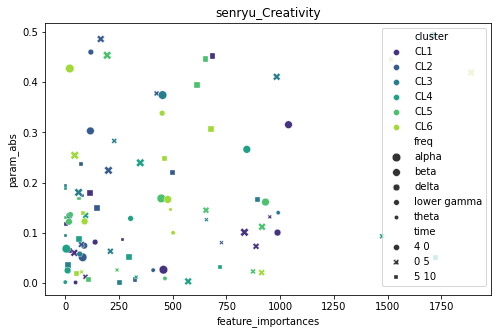

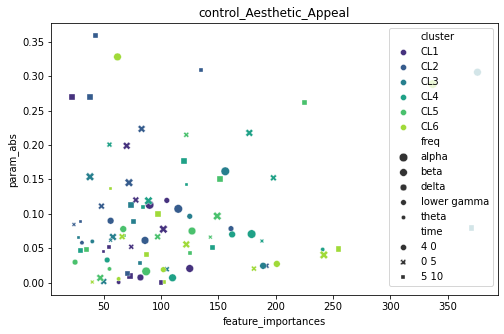

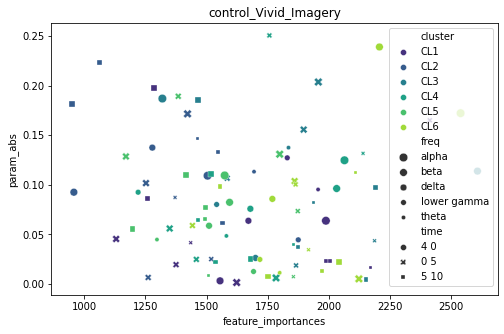

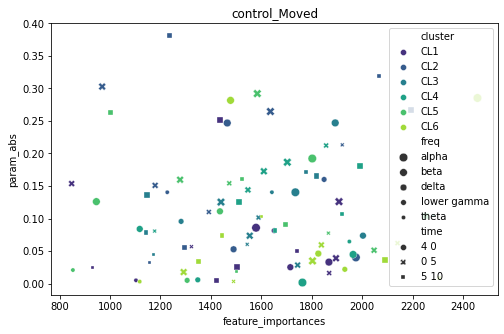

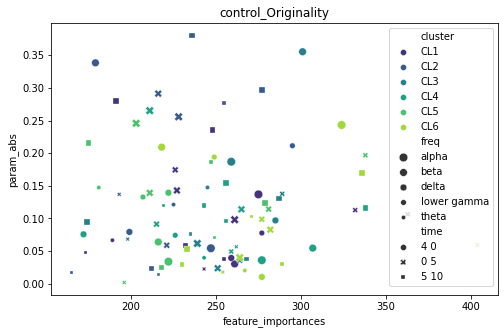

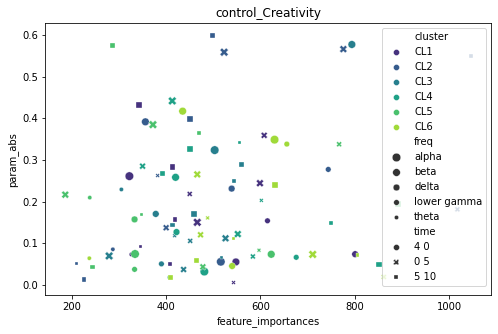

In [108]:
for i, (dataset_name, dataset) in enumerate(all_coef.items()):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=dataset, x='feature_importances',  # Replace with your column names
        y='param_abs',  # Replace with your column names
        hue='cluster',  # Color by cluster
        style='time',  # Different marker shape for timing
        size='freq',  # Different marker size for frequency range
        palette='viridis',  # Color palette
        ax=ax)
    ax.set_title(dataset_name)
    plt.show()

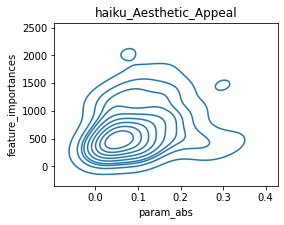

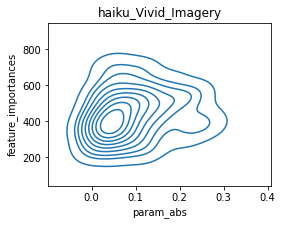

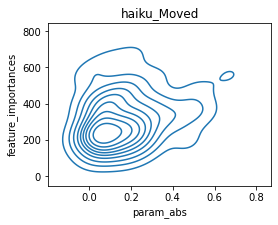

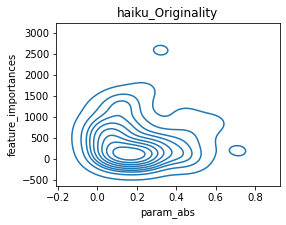

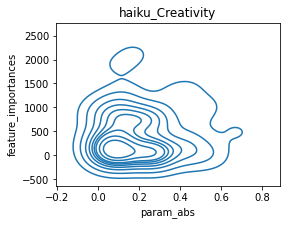

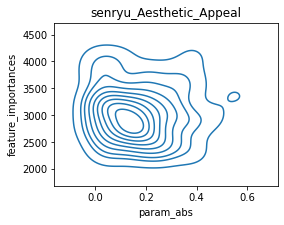

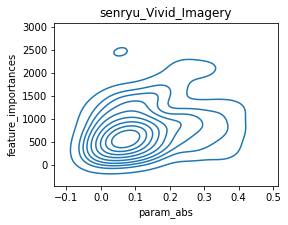

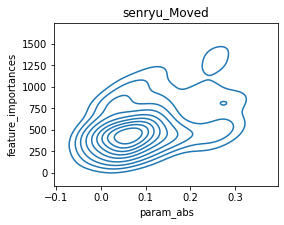

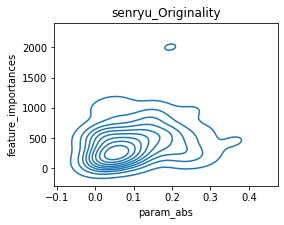

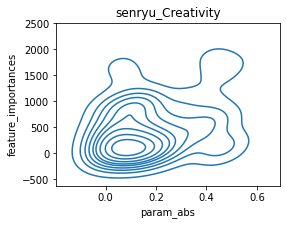

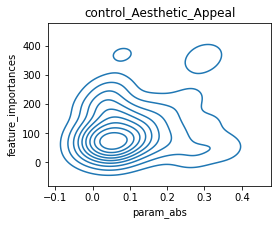

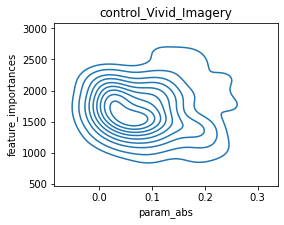

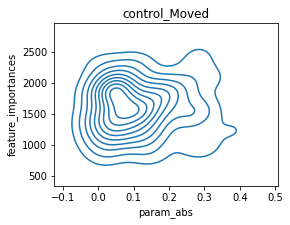

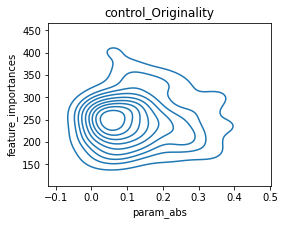

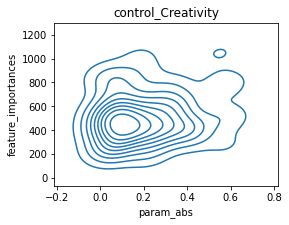

In [109]:
for i, (dataset_name, dataset) in enumerate(all_coef.items()):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title(dataset_name)
    
    sns.kdeplot(data=dataset, x='param_abs', y='feature_importances', ax = ax)
    plt.show()

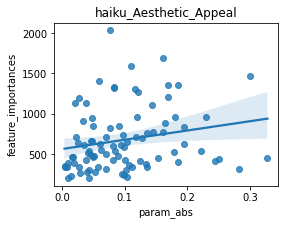

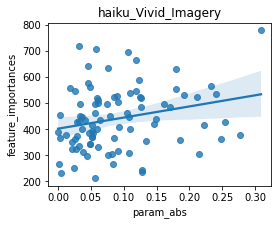

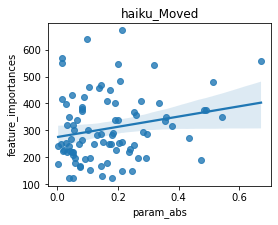

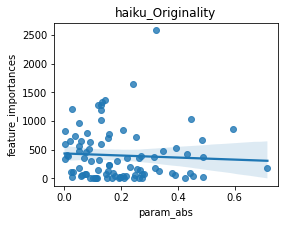

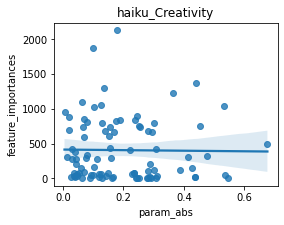

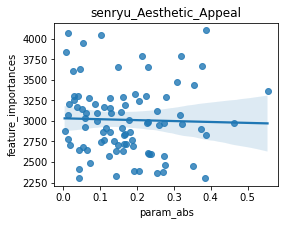

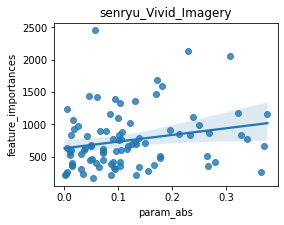

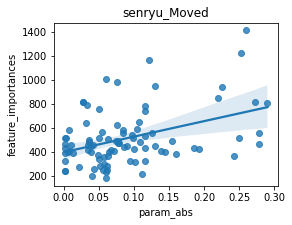

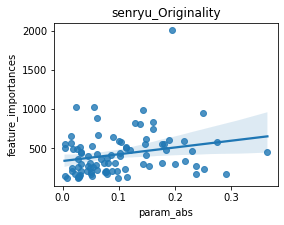

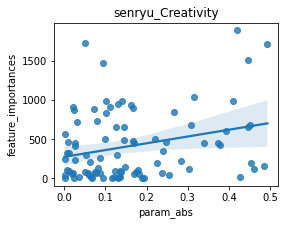

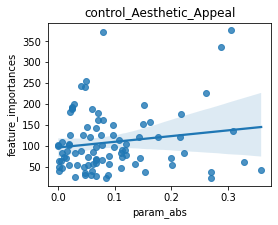

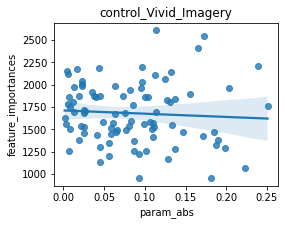

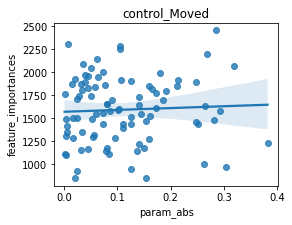

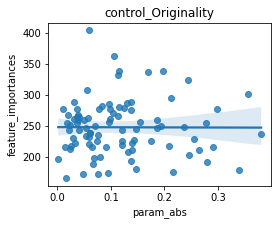

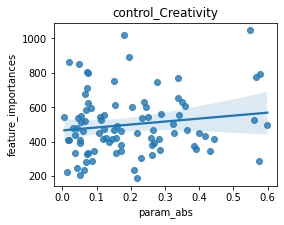

In [110]:
for i, (dataset_name, dataset) in enumerate(all_coef.items()):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title(dataset_name)
    
    sns.regplot(data=dataset, x='param_abs', y='feature_importances', ax=ax)
    plt.show()

haiku_Aesthetic_Appeal


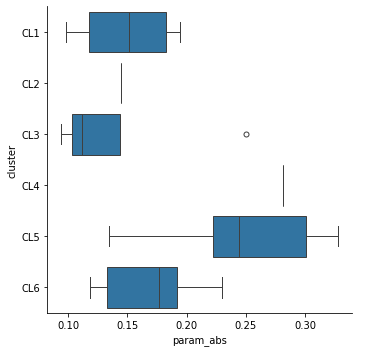

haiku_Vivid_Imagery


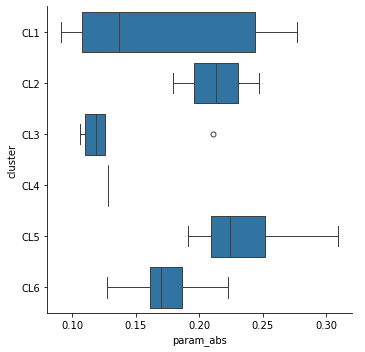

haiku_Moved


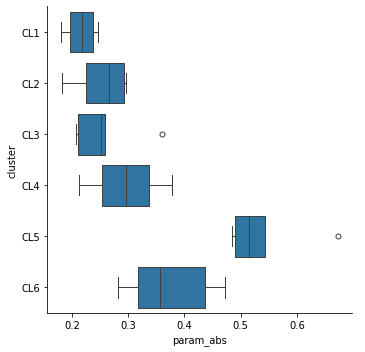

haiku_Originality


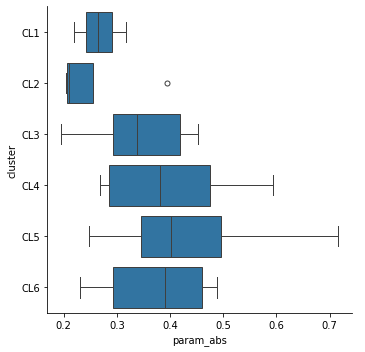

haiku_Creativity


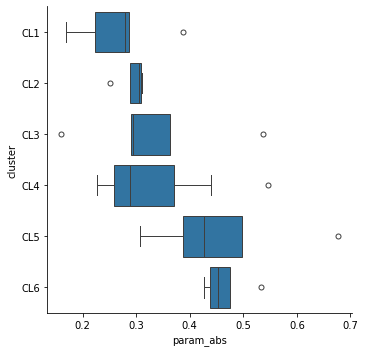

senryu_Aesthetic_Appeal


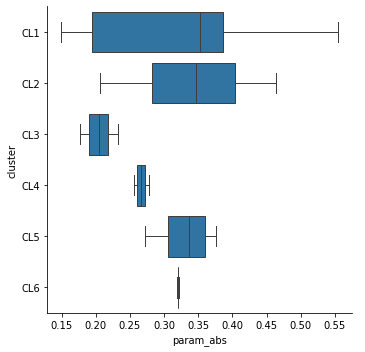

senryu_Vivid_Imagery


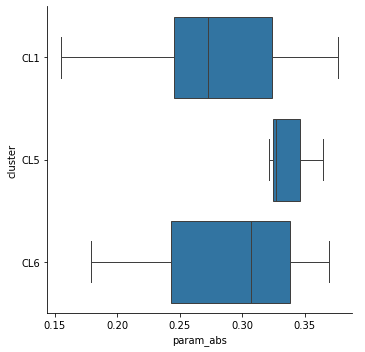

senryu_Moved


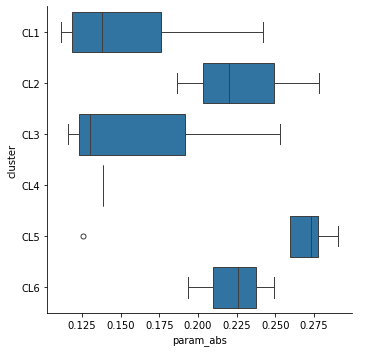

senryu_Originality


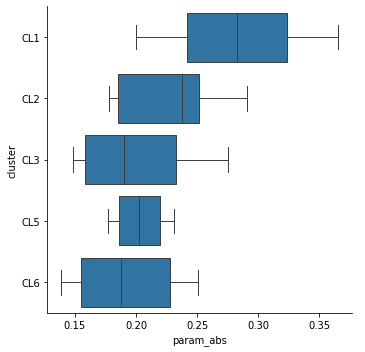

senryu_Creativity


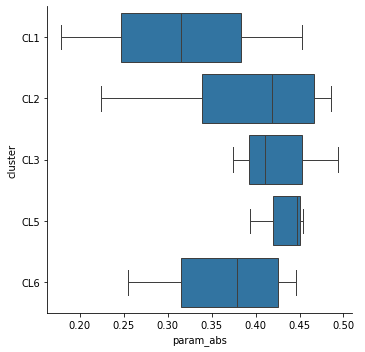

control_Aesthetic_Appeal


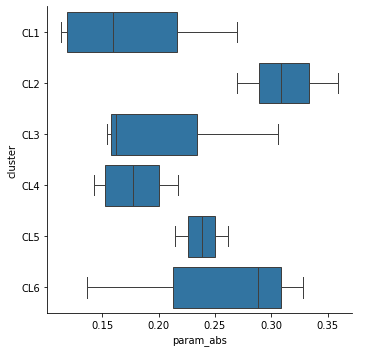

control_Vivid_Imagery


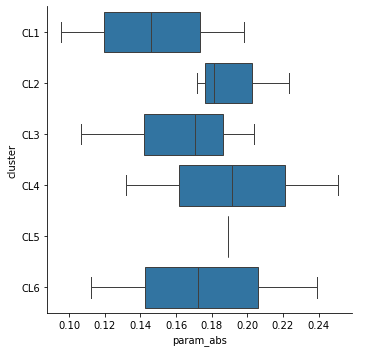

control_Moved


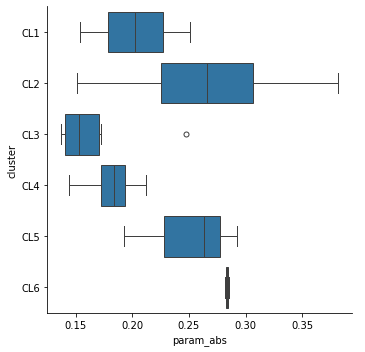

control_Originality


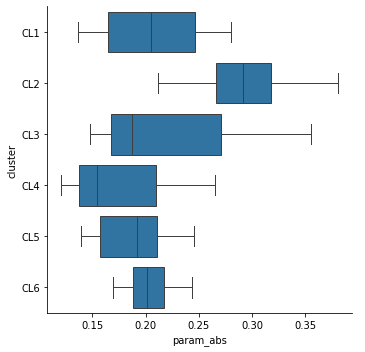

control_Creativity


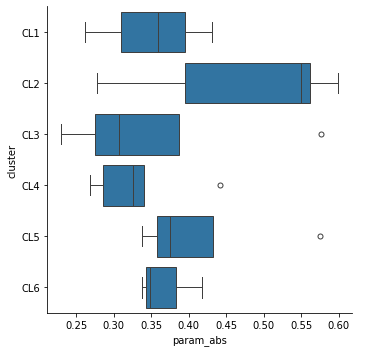

In [111]:
for i, (dataset_name, dataset) in enumerate(all_coef.items()):
    print(dataset_name)
    plt.figsize=(5, 3)
    sns.catplot(
    dataset[dataset.p_values<=0.05], x="param_abs", y="cluster", kind='box')
    plt.show()

haiku_Aesthetic_Appeal


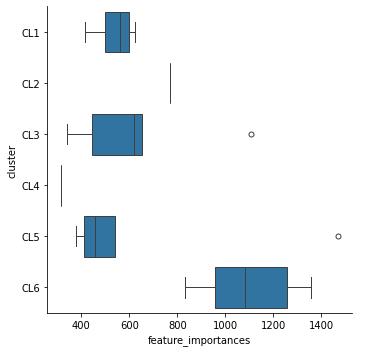

haiku_Vivid_Imagery


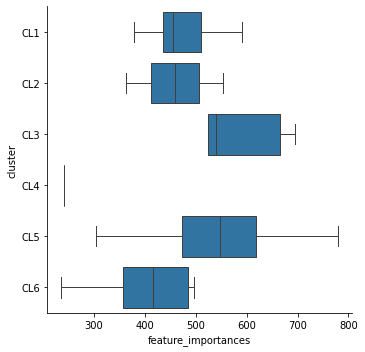

haiku_Moved


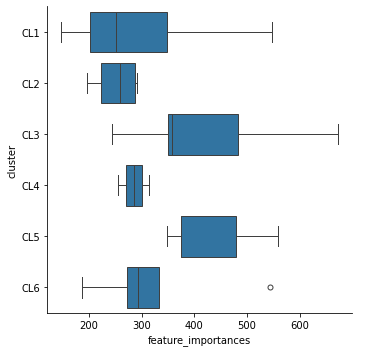

haiku_Originality


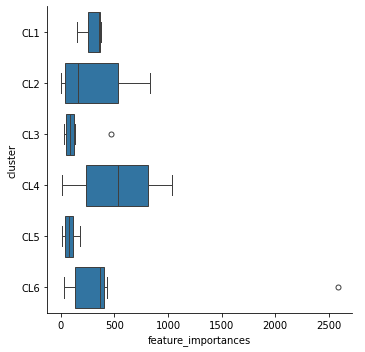

haiku_Creativity


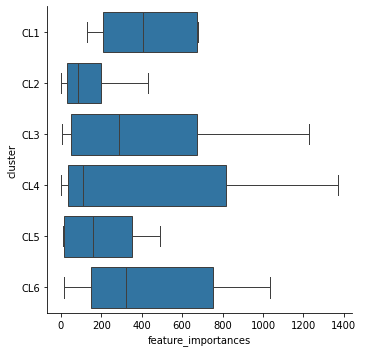

senryu_Aesthetic_Appeal


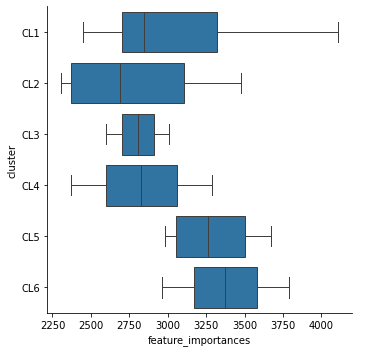

senryu_Vivid_Imagery


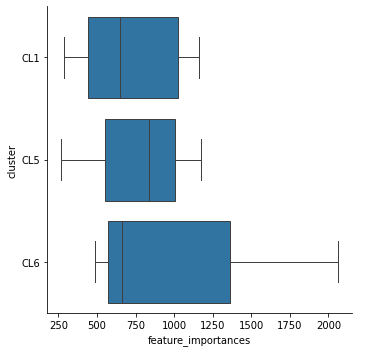

senryu_Moved


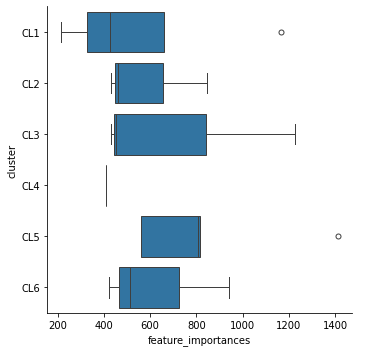

senryu_Originality


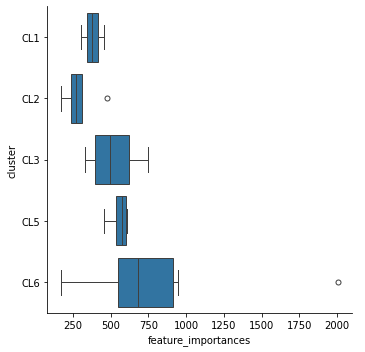

senryu_Creativity


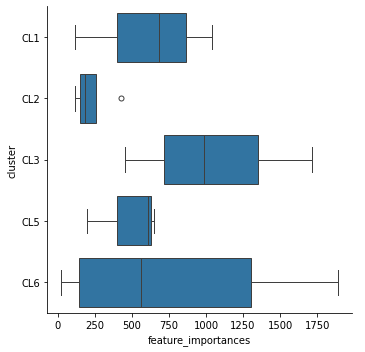

control_Aesthetic_Appeal


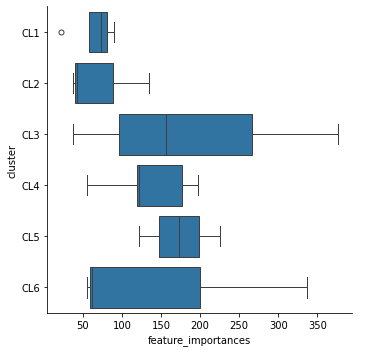

control_Vivid_Imagery


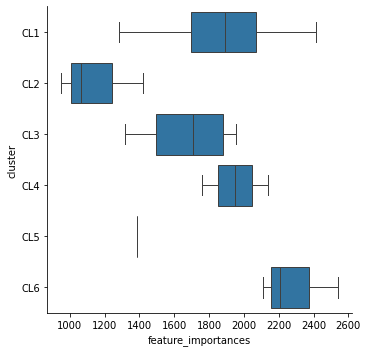

control_Moved


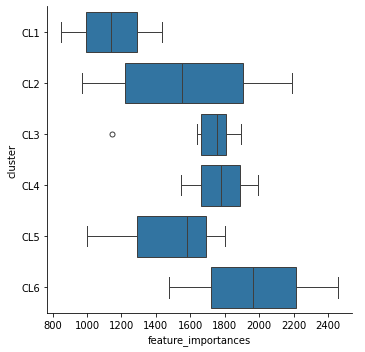

control_Originality


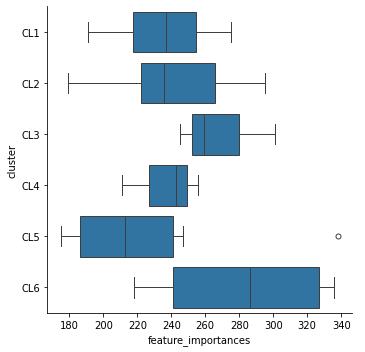

control_Creativity


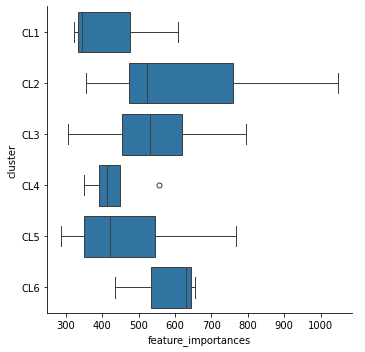

In [112]:
for i, (dataset_name, dataset) in enumerate(all_coef.items()):
    print(dataset_name)
    plt.figsize=(5, 3)
    sns.catplot(
    dataset[dataset.p_values<=0.05], x="feature_importances", y="cluster", kind='box')
    plt.show()



In [113]:
for i, (dataset_name, dataset) in enumerate(all_coef.items()):
    print("-------------")
    print(dataset_name)
    feat_ordered = dataset[dataset.p_values<=0.05].sort_values(by='param_abs', ascending=False)
    feat_ordered['rank'] = range(1, len(feat_ordered) + 1)
    
    print(feat_ordered.groupby('cluster')['rank'].mean())
    print(feat_ordered.groupby('freq')['rank'].mean())
    print(feat_ordered.groupby('time')['rank'].mean())

-------------
haiku_Aesthetic_Appeal
cluster
CL1    14.250000
CL2    13.000000
CL3    15.800000
CL4     3.000000
CL5     6.000000
CL6    11.833333
Name: rank, dtype: float64
freq
alpha           7.833333
beta            6.400000
delta          19.333333
lower gamma     8.666667
theta          18.000000
Name: rank, dtype: float64
time
0 5      9.625000
4 0      9.333333
5 10    13.454545
Name: rank, dtype: float64
-------------
haiku_Vivid_Imagery
cluster
CL1    14.375
CL2     8.000
CL3    18.200
CL4    16.000
CL5     6.250
CL6    12.400
Name: rank, dtype: float64
freq
alpha          13.375
beta            5.750
delta          18.000
lower gamma     5.750
theta          20.500
Name: rank, dtype: float64
time
0 5     11.500000
4 0      9.857143
5 10    16.400000
Name: rank, dtype: float64
-------------
haiku_Moved
cluster
CL1    21.00
CL2    16.75
CL3    16.60
CL4    14.00
CL5     3.00
CL6     9.60
Name: rank, dtype: float64
freq
alpha           8.666667
beta           10.142857
delta   

In [114]:
for i, (dataset_name, dataset) in enumerate(all_coef.items()):
    print("-------------")
    print(dataset_name)
    feat_ordered_xgb = dataset[dataset.p_values<=0.05].sort_values(by='feature_importances', ascending=False)
    feat_ordered_xgb['rank'] = range(1, len(feat_ordered_xgb) + 1)
    
    print(feat_ordered_xgb.groupby('cluster')['rank'].mean())
    print(feat_ordered_xgb.groupby('freq')['rank'].mean())
    print(feat_ordered_xgb.groupby('time')['rank'].mean())

-------------
haiku_Aesthetic_Appeal
cluster
CL1    14.25
CL2     9.00
CL3    13.00
CL4    22.00
CL5    14.00
CL6     5.00
Name: rank, dtype: float64
freq
alpha          11.000000
beta           10.800000
delta          15.000000
lower gamma     9.666667
theta          11.800000
Name: rank, dtype: float64
time
0 5     11.875000
4 0     17.000000
5 10     9.727273
Name: rank, dtype: float64
-------------
haiku_Vivid_Imagery
cluster
CL1    13.75
CL2    13.50
CL3     6.60
CL4    24.00
CL5     9.50
CL6    18.60
Name: rank, dtype: float64
freq
alpha           9.75
beta           13.50
delta          15.80
lower gamma    17.00
theta          11.50
Name: rank, dtype: float64
time
0 5     13.5
4 0     12.0
5 10    13.3
Name: rank, dtype: float64
-------------
haiku_Moved
cluster
CL1    16.75
CL2    18.75
CL3     9.00
CL4    16.00
CL5     6.80
CL6    14.40
Name: rank, dtype: float64
freq
alpha          10.833333
beta           14.285714
delta          20.250000
lower gamma    11.000000
theta   